<a href="https://colab.research.google.com/github/lxndrkrln/My-Projects/blob/main/%D0%BC%D0%B5%D1%82%D0%BE%D0%B4%D1%8B%20%D0%BC%D0%B0%D1%88%D0%B8%D0%BD%D0%BD%D0%BE%D0%B3%D0%BE%20%D0%BE%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('TCC.csv')

# 1. Первичный осмотр
print("=== SHAPE ===")
print(df.shape)

print("\n=== INFO ===")
df.info()

print("\n=== HEAD ===")
print(df.head())

print("\n=== DESCRIBE ===")
print(df.describe())

print("\n=== ПРОПУСКИ ===")
print(df.isnull().sum())

print("\n=== ЦЕЛЕВАЯ ПЕРЕМЕННАЯ ===")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).round(3))

=== SHAPE ===
(7043, 21)

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Pap

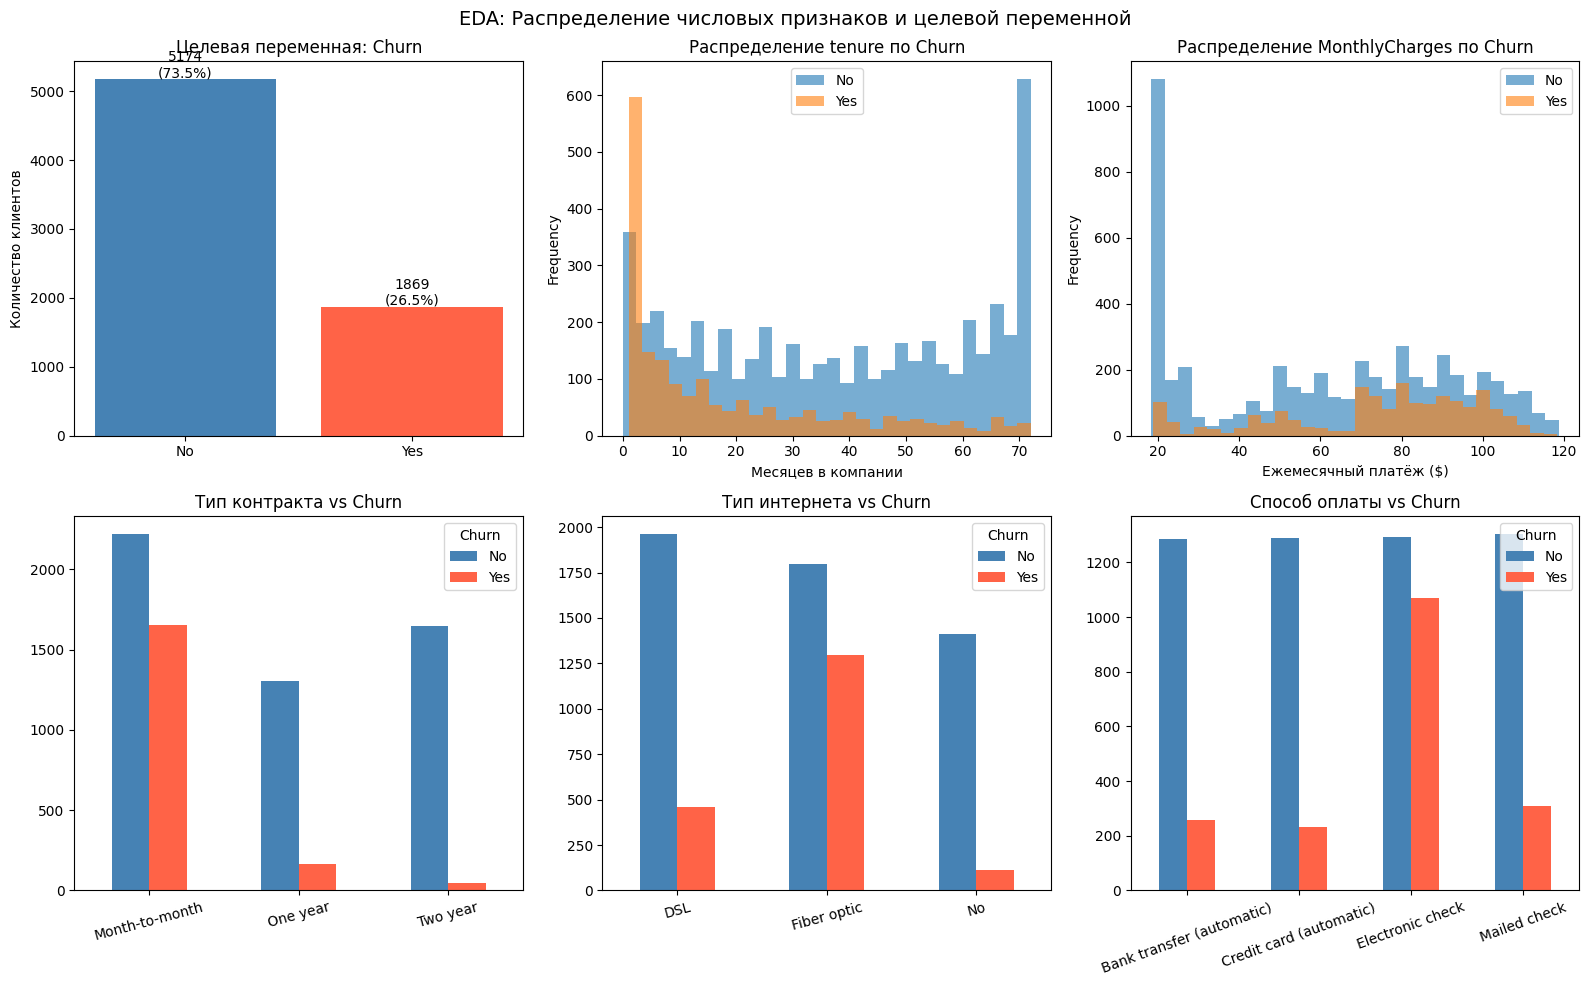

График сохранён: eda_plots.png


In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EDA: Распределение числовых признаков и целевой переменной', fontsize=14)

ax = axes[0, 0]
churn_counts = df['Churn'].value_counts()
ax.bar(churn_counts.index, churn_counts.values, color=['steelblue', 'tomato'])
ax.set_title('Целевая переменная: Churn')
ax.set_ylabel('Количество клиентов')
for i, v in enumerate(churn_counts.values):
    ax.text(i, v + 30, f'{v}\n({v/len(df)*100:.1f}%)', ha='center')

ax = axes[0, 1]
df.groupby('Churn')['tenure'].plot(kind='hist', bins=30, alpha=0.6, ax=ax, legend=True)
ax.set_title('Распределение tenure по Churn')
ax.set_xlabel('Месяцев в компании')

ax = axes[0, 2]
df.groupby('Churn')['MonthlyCharges'].plot(kind='hist', bins=30, alpha=0.6, ax=ax, legend=True)
ax.set_title('Распределение MonthlyCharges по Churn')
ax.set_xlabel('Ежемесячный платёж ($)')

ax = axes[1, 0]
contract_churn = df.groupby(['Contract', 'Churn']).size().unstack()
contract_churn.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
ax.set_title('Тип контракта vs Churn')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=15)

ax = axes[1, 1]
internet_churn = df.groupby(['InternetService', 'Churn']).size().unstack()
internet_churn.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
ax.set_title('Тип интернета vs Churn')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=15)

ax = axes[1, 2]
payment_churn = df.groupby(['PaymentMethod', 'Churn']).size().unstack()
payment_churn.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
ax.set_title('Способ оплаты vs Churn')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("График сохранён: eda_plots.png")

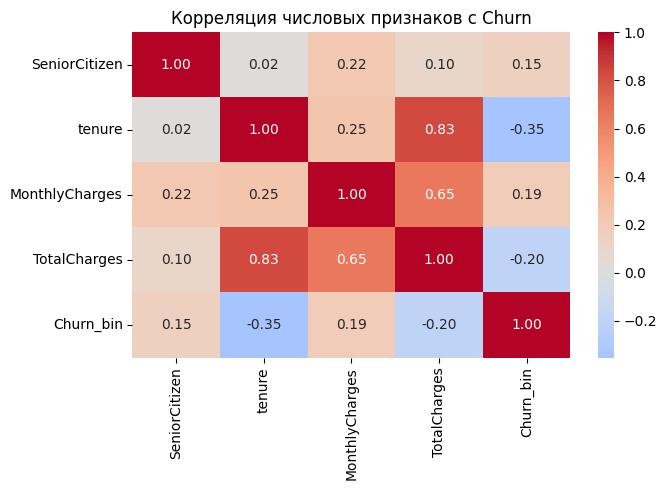

График сохранён: correlation_heatmap.png


In [5]:
df_corr = df.copy()
df_corr['Churn_bin'] = (df_corr['Churn'] == 'Yes').astype(int)

numeric_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_bin']
corr_matrix = df_corr[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляция числовых признаков с Churn')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()
print("График сохранён: correlation_heatmap.png")

In [6]:

df = pd.read_csv('TCC.csv')
df = df.drop(columns=['customerID'])
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Пропуски после конвертации TotalCharges:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nСтроки с пропуском в TotalCharges:")
print(df[df['TotalCharges'].isna()][['tenure', 'MonthlyCharges', 'TotalCharges']])

Пропуски после конвертации TotalCharges:
TotalCharges    11
dtype: int64

Строки с пропуском в TotalCharges:
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN
3331       0           19.85           NaN
3826       0           25.35           NaN
4380       0           20.00           NaN
5218       0           19.70           NaN
6670       0           73.35           NaN
6754       0           61.90           NaN


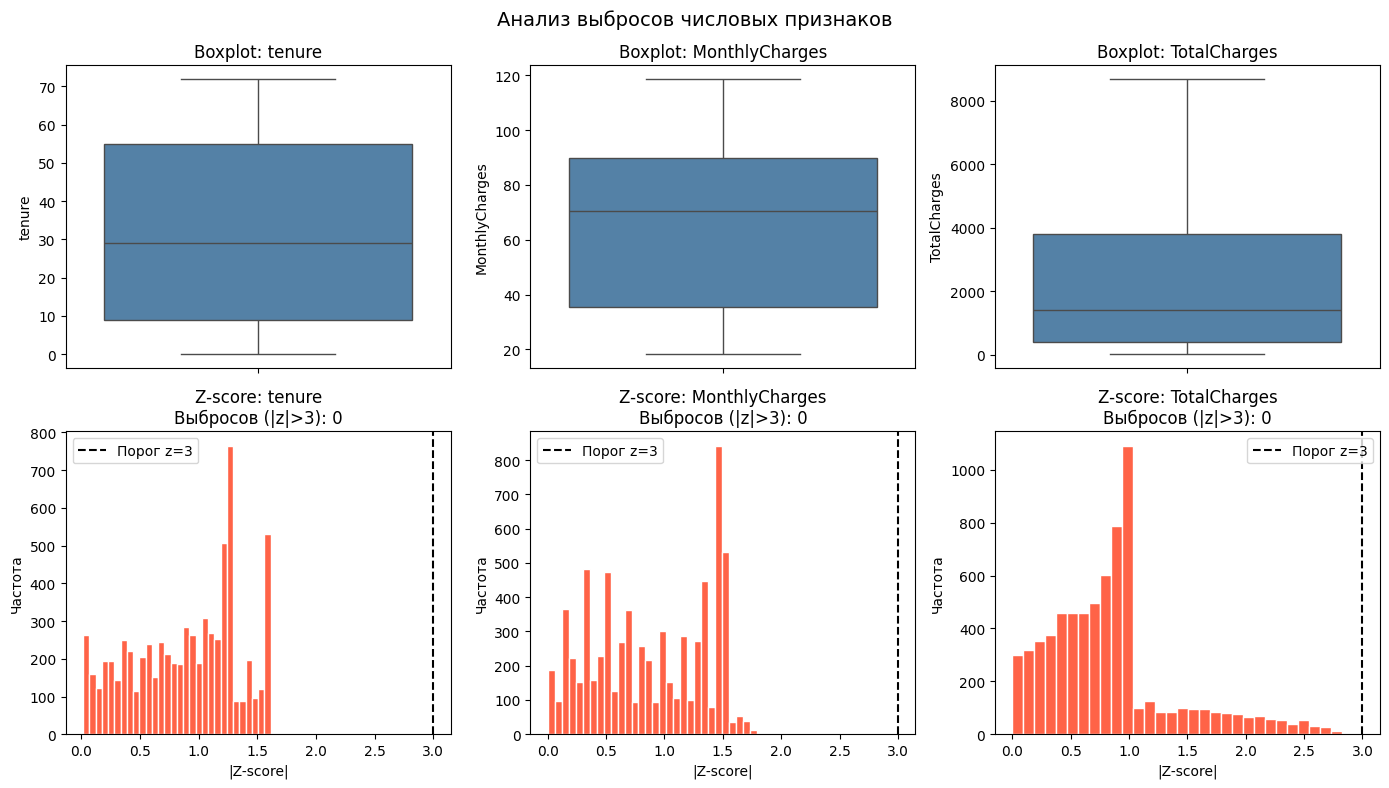

График сохранён: outliers.png


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Анализ выбросов числовых признаков', fontsize=14)

for i, col in enumerate(numeric_cols):
    ax = axes[0, i]
    sns.boxplot(y=df[col], ax=ax, color='steelblue')
    ax.set_title(f'Boxplot: {col}')
    ax.set_ylabel(col)

for i, col in enumerate(numeric_cols):
    ax = axes[1, i]
    z_scores = np.abs(stats.zscore(df[col].dropna()))
    ax.hist(z_scores, bins=30, color='tomato', edgecolor='white')
    ax.axvline(x=3, color='black', linestyle='--', label='Порог z=3')
    outliers = (z_scores > 3).sum()
    ax.set_title(f'Z-score: {col}\nВыбросов (|z|>3): {outliers}')
    ax.set_xlabel('|Z-score|')
    ax.set_ylabel('Частота')
    ax.legend()

plt.tight_layout()
plt.savefig('outliers.png', dpi=150, bbox_inches='tight')
plt.show()
print("График сохранён: outliers.png")

In [11]:
df = df.dropna(subset=['TotalCharges'])
print(f"Строк после удаления: {len(df)}")
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
print("\nРаспределение Churn после кодирования:")
print(df['Churn'].value_counts())

Строк после удаления: 7032

Распределение Churn после кодирования:
Churn
0    7032
Name: count, dtype: int64


In [12]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Категориальные колонки:", cat_cols)
print(f"Количество: {len(cat_cols)}")

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(f"\nРазмер до кодирования:  {df.shape}")
print(f"Размер после кодирования: {df_encoded.shape}")
print(f"\nНовые колонки:\n{df_encoded.columns.tolist()}")

Категориальные колонки: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Количество: 15

Размер до кодирования:  (7032, 20)
Размер после кодирования: (7032, 31)

Новые колонки:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two 

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"\nПропорции классов в train:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nПропорции классов в test:")
print(y_test.value_counts(normalize=True).round(3))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("\nМасштабирование выполнено.")
print(f"Среднее tenure до: {X_train['tenure'].mean():.2f}")
print(f"Среднее tenure после: {X_train_scaled['tenure'].mean():.4f}")

X_train: (5625, 30), X_test: (1407, 30)

Пропорции классов в train:
Churn
0    0.734
1    0.266
Name: proportion, dtype: float64

Пропорции классов в test:
Churn
0    0.734
1    0.266
Name: proportion, dtype: float64

Масштабирование выполнено.
Среднее tenure до: 32.56
Среднее tenure после: -0.0000


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
print("✓ Логистическая регрессия обучена")

dt = DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)
dt.fit(X_train, y_train)
print("✓ Дерево решений обучено")

rf = RandomForestClassifier(class_weight='balanced', n_estimators=100,
                             max_depth=10, random_state=42)
rf.fit(X_train, y_train)
print("✓ Случайный лес обучен")

✓ Логистическая регрессия обучена
✓ Дерево решений обучено
✓ Случайный лес обучен


In [14]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, RocCurveDisplay)

def evaluate_model(name, model, X_test_data, y_test):
    y_pred = model.predict(X_test_data)
    y_proba = model.predict_proba(X_test_data)[:, 1]

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
    print(f"  Precision: {precision_score(y_test, y_pred):.3f}")
    print(f"  Recall:    {recall_score(y_test, y_pred):.3f}")
    print(f"  F1-score:  {f1_score(y_test, y_pred):.3f}")
    print(f"  ROC-AUC:   {roc_auc_score(y_test, y_proba):.3f}")
    print(f"\n  Classification report:")
    print(classification_report(y_test, y_pred, target_names=['Остался', 'Ушёл']))

    return {
        'name': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'y_pred': y_pred,
        'y_proba': y_proba
    }

results_lr = evaluate_model("Логистическая регрессия", lr, X_test_scaled, y_test)
results_dt = evaluate_model("Дерево решений", dt, X_test, y_test)
results_rf = evaluate_model("Случайный лес", rf, X_test, y_test)


  Логистическая регрессия
  Accuracy:  0.726
  Precision: 0.491
  Recall:    0.797
  F1-score:  0.608
  ROC-AUC:   0.835

  Classification report:
              precision    recall  f1-score   support

     Остался       0.91      0.70      0.79      1033
        Ушёл       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407


  Дерево решений
  Accuracy:  0.706
  Precision: 0.468
  Recall:    0.783
  F1-score:  0.586
  ROC-AUC:   0.818

  Classification report:
              precision    recall  f1-score   support

     Остался       0.90      0.68      0.77      1033
        Ушёл       0.47      0.78      0.59       374

    accuracy                           0.71      1407
   macro avg       0.68      0.73      0.68      1407
weighted avg       0.78      0.71      0.72      1407


  Случайный лес
  Accuracy:  0.772
  Precision: 0.552
  Re

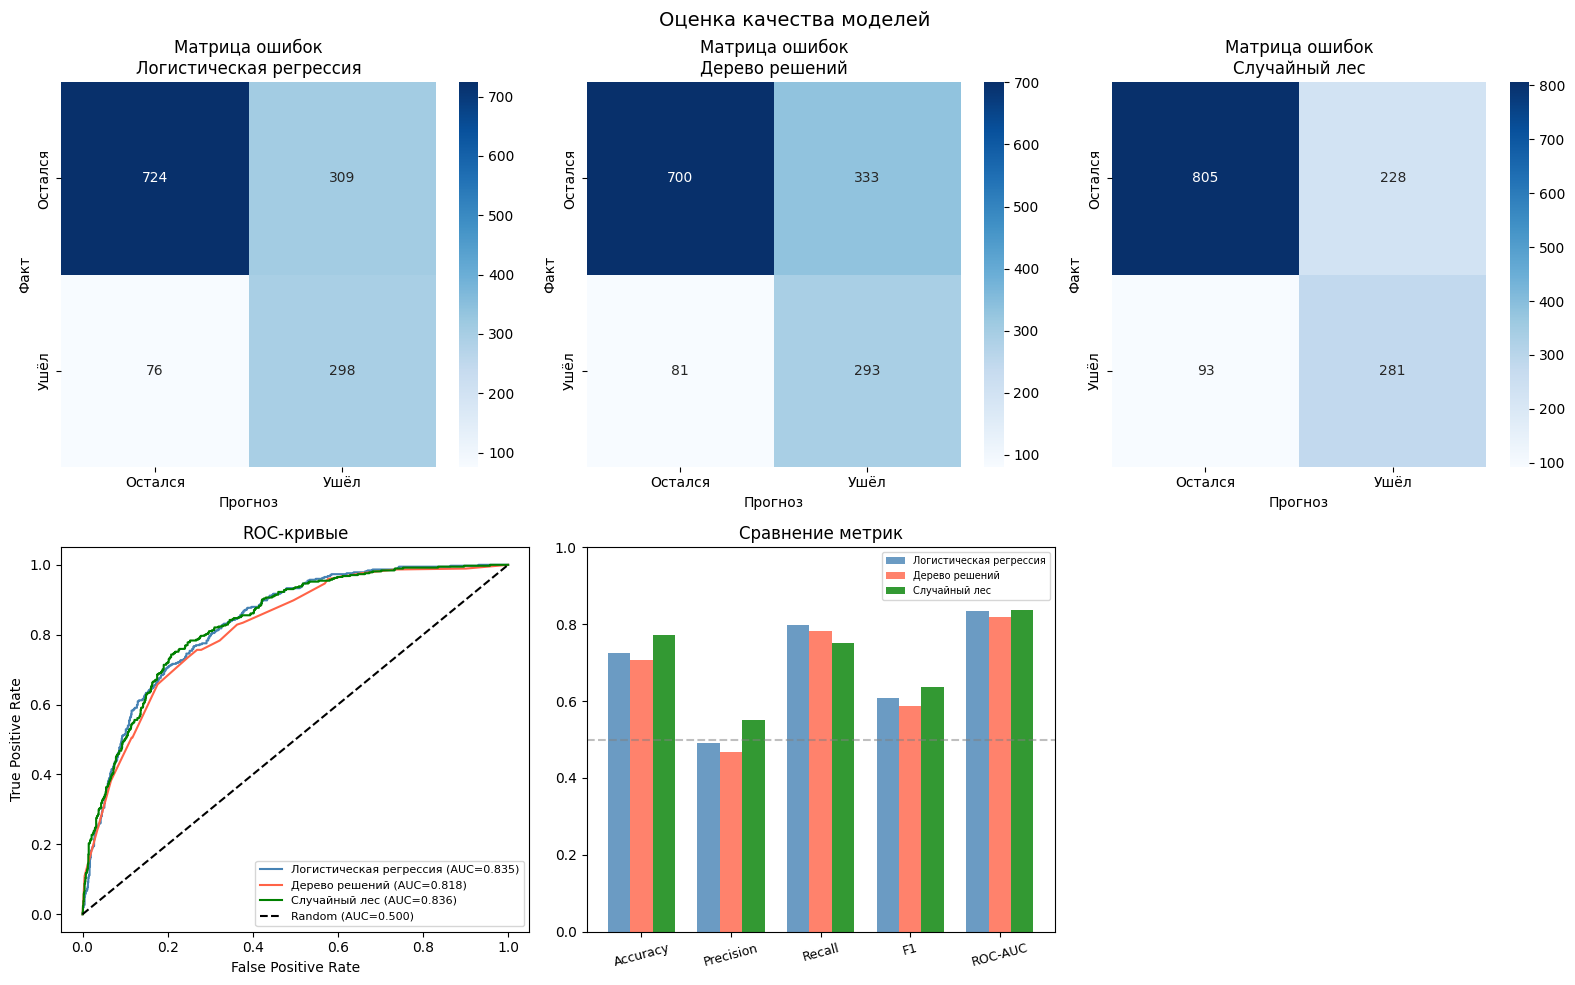

График сохранён: model_evaluation.png


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Оценка качества моделей', fontsize=14)

models_results = [results_lr, results_dt, results_rf]
model_names = ['Логистическая регрессия', 'Дерево решений', 'Случайный лес']

for i, (res, name) in enumerate(zip(models_results, model_names)):
    ax = axes[0, i]
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Остался', 'Ушёл'],
                yticklabels=['Остался', 'Ушёл'])
    ax.set_title(f'Матрица ошибок\n{name}')
    ax.set_ylabel('Факт')
    ax.set_xlabel('Прогноз')

ax = axes[1, 0]
from sklearn.metrics import roc_curve
colors = ['steelblue', 'tomato', 'green']
for res, name, color in zip(models_results, model_names, colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax.plot(fpr, tpr, color=color,
            label=f"{name} (AUC={res['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC-кривые')
ax.legend(fontsize=8)

ax = axes[1, 1]
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
x = np.arange(len(metrics))
width = 0.25
for i, (res, name, color) in enumerate(zip(models_results, model_names, colors)):
    values = [res[m] for m in metrics]
    ax.bar(x + i*width, values, width, label=name, color=color, alpha=0.8)
ax.set_xticks(x + width)
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'],
                    rotation=15, fontsize=9)
ax.set_ylim(0, 1)
ax.set_title('Сравнение метрик')
ax.legend(fontsize=7)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

axes[1, 2].set_visible(False)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("График сохранён: model_evaluation.png")

In [24]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший F1 на кросс-валидации: {grid_search.best_score_:.3f}")

rf_best = grid_search.best_estimator_
results_rf_best = evaluate_model("Случайный лес (GridSearchCV)", rf_best, X_test, y_test)

print(f"\nСравнение:")
print(f"RF исходный    — F1: {results_rf['f1']:.3f}, ROC-AUC: {results_rf['roc_auc']:.3f}")
print(f"RF GridSearchCV — F1: {results_rf_best['f1']:.3f}, ROC-AUC: {results_rf_best['roc_auc']:.3f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Лучшие параметры: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Лучший F1 на кросс-валидации: 0.632

  Случайный лес (GridSearchCV)
  Accuracy:  0.772
  Precision: 0.552
  Recall:    0.751
  F1-score:  0.636
  ROC-AUC:   0.836

  Classification report:
              precision    recall  f1-score   support

     Остался       0.90      0.78      0.83      1033
        Ушёл       0.55      0.75      0.64       374

    accuracy                           0.77      1407
   macro avg       0.72      0.77      0.74      1407
weighted avg       0.80      0.77      0.78      1407


Сравнение:
RF исходный    — F1: 0.636, ROC-AUC: 0.836
RF GridSearchCV — F1: 0.636, ROC-AUC: 0.836


Топ-10 важных признаков:
                           feature  importance
1                           tenure    0.175830
3                     TotalCharges    0.140220
2                   MonthlyCharges    0.113644
25               Contract_Two year    0.096202
10     InternetService_Fiber optic    0.061386
28  PaymentMethod_Electronic check    0.052787
24               Contract_One year    0.044214
13              OnlineSecurity_Yes    0.036916
19                 TechSupport_Yes    0.025268
26            PaperlessBilling_Yes    0.018383


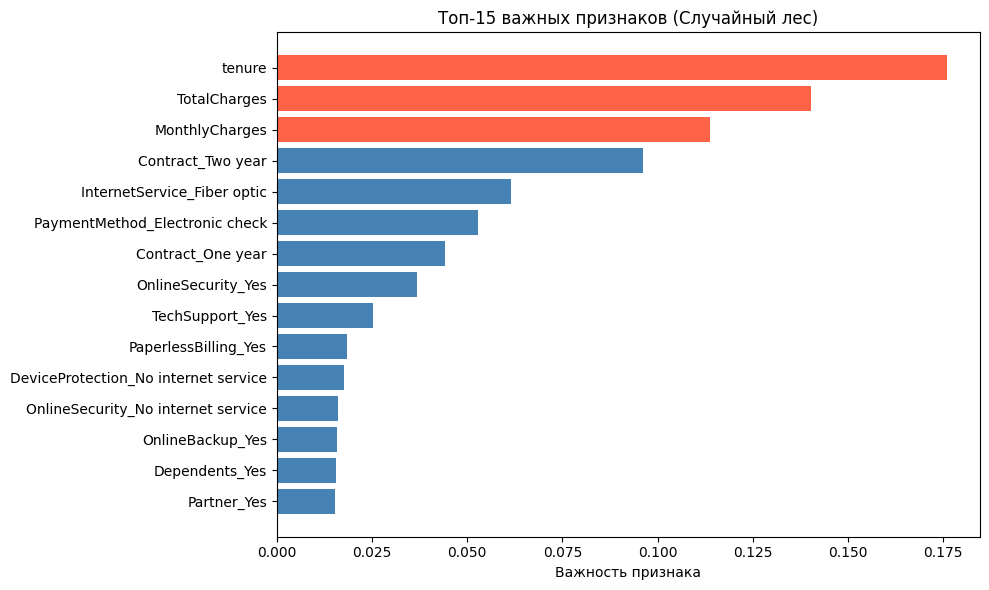

График сохранён: feature_importance.png


In [16]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Топ-10 важных признаков:")
print(feature_importance.head(10))

plt.figure(figsize=(10, 6))
top15 = feature_importance.head(15)
colors = ['tomato' if i < 3 else 'steelblue' for i in range(len(top15))]
plt.barh(top15['feature'][::-1], top15['importance'][::-1], color=colors[::-1])
plt.xlabel('Важность признака')
plt.title('Топ-15 важных признаков (Случайный лес)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("График сохранён: feature_importance.png")